In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [30]:
df=pd.read_csv("CAR - CAR (1).csv");
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000.0,83000.0,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,90000.0,Diesel,Individual,Manual,First Owner


In [31]:
df.info();


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4340 non-null   int64  
 2   selling_price  4339 non-null   float64
 3   km_driven      4338 non-null   float64
 4   fuel           4340 non-null   object 
 5   seller_type    4340 non-null   object 
 6   transmission   4340 non-null   object 
 7   owner          4340 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 271.4+ KB


In [32]:
df.describe

<bound method NDFrame.describe of                                      name  year  selling_price  km_driven  \
0                           Maruti 800 AC  2007        60000.0    70000.0   
1                Maruti Wagon R LXI Minor  2007       135000.0    50000.0   
2                    Hyundai Verna 1.6 SX  2012       600000.0   100000.0   
3                  Datsun RediGO T Option  2017       250000.0    46000.0   
4                   Honda Amaze VX i-DTEC  2014       450000.0   141000.0   
...                                   ...   ...            ...        ...   
4335  Hyundai i20 Magna 1.4 CRDi (Diesel)  2014       409999.0    80000.0   
4336           Hyundai i20 Magna 1.4 CRDi  2014       409999.0    80000.0   
4337                  Maruti 800 AC BSIII  2009       110000.0    83000.0   
4338     Hyundai Creta 1.6 CRDi SX Option  2016       865000.0    90000.0   
4339                     Renault KWID RXT  2016       225000.0    40000.0   

        fuel seller_type transmission    

In [33]:
df.shape

(4340, 8)

In [34]:
df.dtypes

name              object
year               int64
selling_price    float64
km_driven        float64
fuel              object
seller_type       object
transmission      object
owner             object
dtype: object

In [35]:
#Datacleaning

In [36]:
df.isna().sum()

name             0
year             0
selling_price    1
km_driven        2
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [37]:
df['selling_price']=df['selling_price'].fillna(df['selling_price'].mean())

In [38]:
df['km_driven']=df['km_driven'].fillna(df['km_driven'].mean())

In [39]:
df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [40]:
#Data Integration

In [41]:
df1=df[df['year']==2007]

In [42]:
df2=df[df['fuel']=='Petrol']

In [76]:
df['km_driven'].max()

np.float64(1.0)

In [43]:
merge = pd.merge(df1,df2,on='year')
merge

,name_x,year,selling_price_x,km_driven_x,fuel_x,seller_type_x,transmission_x,owner_x,name_y,selling_price_y,km_driven_y,fuel_y,seller_type_y,transmission_y,owner_y
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti 800 AC,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti Wagon R LXI Minor,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti Alto LX BSIII,140000.0,125000.0,Petrol,Individual,Manual,First Owner
3,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti 800 AC,60000.0,70000.0,Petrol,Individual,Manual,First Owner
4,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti Wagon R LXI Minor,135000.0,50000.0,Petrol,Individual,Manual,First Owner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13127,Honda City 1.5 GXI,2007,190000.0,115000.0,Petrol,Dealer,Manual,Second Owner,Hyundai Verna i (Petrol),123000.0,50000.0,Petrol,Individual,Manual,Second Owner
13128,Honda City 1.5 GXI,2007,190000.0,115000.0,Petrol,Dealer,Manual,Second Owner,Maruti Wagon R LXI Minor,140000.0,49000.0,Petrol,Dealer,Manual,First Owner
13129,Honda City 1.5 GXI,2007,190000.0,115000.0,Petrol,Dealer,Manual,Second Owner,Maruti SX4 Zxi BSIII,160000.0,80000.0,Petrol,Individual,Manual,Third Owner
13130,Honda City 1.5 GXI,2007,190000.0,115000.0,Petrol,Dealer,Manual,Second Owner,Honda City 1.5 GXI,190000.0,115000.0,Petrol,Dealer,Manual,Second Owner


In [69]:
df['fuel']=df['fuel'].map({'Petrol':0,'Diesel':2,'CNG':3,'LPG':3,'Electric':4})
df['seller_type']=df['seller_type'].map({'Individual':0,'Dealer':1,'Trustmark Dealer':2})
df['transmission']=df['transmission'].map({'Manual':0,'Automatic':1})
df['owner']=df['owner'].map({'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':4})

In [70]:
scaler=MinMaxScaler();
df[['km_driven',]]=scaler.fit_transform(df[['km_driven']])
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000.0,0.086670,0,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000.0,0.061871,0,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000.0,0.123868,2,0,0,0
3,Datsun RediGO T Option,2017,250000.0,0.056911,0,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000.0,0.174705,2,0,0,1
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,0.099069,2,0,0,1
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,0.099069,2,0,0,1
4337,Maruti 800 AC BSIII,2009,110000.0,0.102789,0,0,0,1
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,0.111468,2,0,0,0


In [71]:
df=df[df['selling_price']>0]
df=df[df['km_driven']>0]

In [49]:
x=df[['km_driven']]
y=df['selling_price']

In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [58]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
y_pred=model.predict(x_test)

In [60]:
mean_squared_error(y_test,y_pred)

284848756816.9815

In [61]:
mean_absolute_error(y_test,y_pred)

307714.02018509543

In [62]:
r2_score(y_test,y_pred)

0.02358363539832642

In [63]:
user=float(input("enterkm"))
pred=model.predict([[user]])
pred[0]

enterkm 0.123976


C:\Users\Sanika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(424385.4007711279)

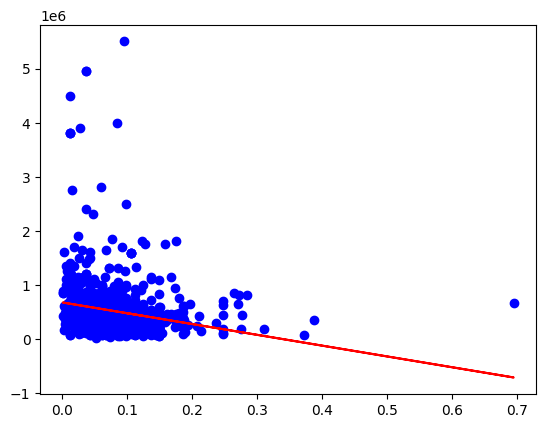

In [68]:
plt.scatter(x_test,y_test,color='blue',label='actual predicted')
plt.plot(x_test ,y_pred, color='red', label='pred')
plt.show()

In [78]:
print("\n--- Predict Price (Multivariate) ---")

year = int(input("Enter Year (e.g., 2015): "))
km = float(input("Enter KM Driven: "))
fuel = int(input("Fuel (Petrol:0, Diesel:1, CNG:2, LPG:3): "))
seller = int(input("Seller (Individual:0, Dealer:1): "))
trans = int(input("Transmission (Manual:0, Auto:1): "))
owner = int(input("Owner (First:0, Second:1, Third:2): "))

user_data = [[year, km, fuel, seller, trans, owner]]

predicted = model.predict(user_data)

print("Predicted Selling Price:", predicted[0])


--- Predict Price (Multivariate) ---


Enter Year (e.g., 2015):  2000
Enter KM Driven:  0.14
Fuel (Petrol:0, Diesel:1, CNG:2, LPG:3):  1
Seller (Individual:0, Dealer:1):  0
Transmission (Manual:0, Auto:1):  1
Owner (First:0, Second:1, Third:2):  1


C:\Users\Sanika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 6 features, but LinearRegression is expecting 1 features as input.

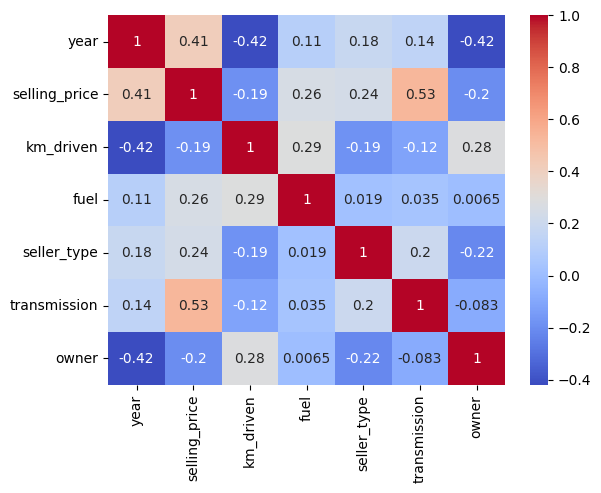

In [73]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()